In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
DATASET_PATH = r"C:\Users\HP\Desktop\sign language translator\archive (5)\asl_alphabet_train\asl_alphabet_train" 
IMAGE_SIZE = (50, 50)      
MAX_IMAGES = 2000          

labels = ['A','B','C','D','E','F','G','H','I','J','K','L','M',
          'N','O','P','Q','R','S','T','U','V','W','X','Y','Z',
          'del','nothing','space']


In [8]:
def limit_images_per_class(dataset_path, max_images):
    for label in labels:
        class_path = os.path.join(dataset_path, label)
        images = os.listdir(class_path)

        if len(images) > max_images:
            remove_count = len(images) - max_images
            remove_images = random.sample(images, remove_count)

            for img in remove_images:
                os.remove(os.path.join(class_path, img))

            print(f"{label}: Reduced to {max_images} images")
        else:
            print(f"{label}: {len(images)} images (unchanged)")


In [9]:
data = []

for label in labels:
    class_path = os.path.join(DATASET_PATH, label)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is not None:
            h, w, c = img.shape
            data.append([label, img_path, h, w, c])

df = pd.DataFrame(data, columns=["Label", "Path", "Height", "Width", "Channels"])
df.head()


,Label,Path,Height,Width,Channels
0,A,C:\Users\HP\Desktop\sign language translator\a...,200,200,3
1,A,C:\Users\HP\Desktop\sign language translator\a...,200,200,3
2,A,C:\Users\HP\Desktop\sign language translator\a...,200,200,3
3,A,C:\Users\HP\Desktop\sign language translator\a...,200,200,3
4,A,C:\Users\HP\Desktop\sign language translator\a...,200,200,3


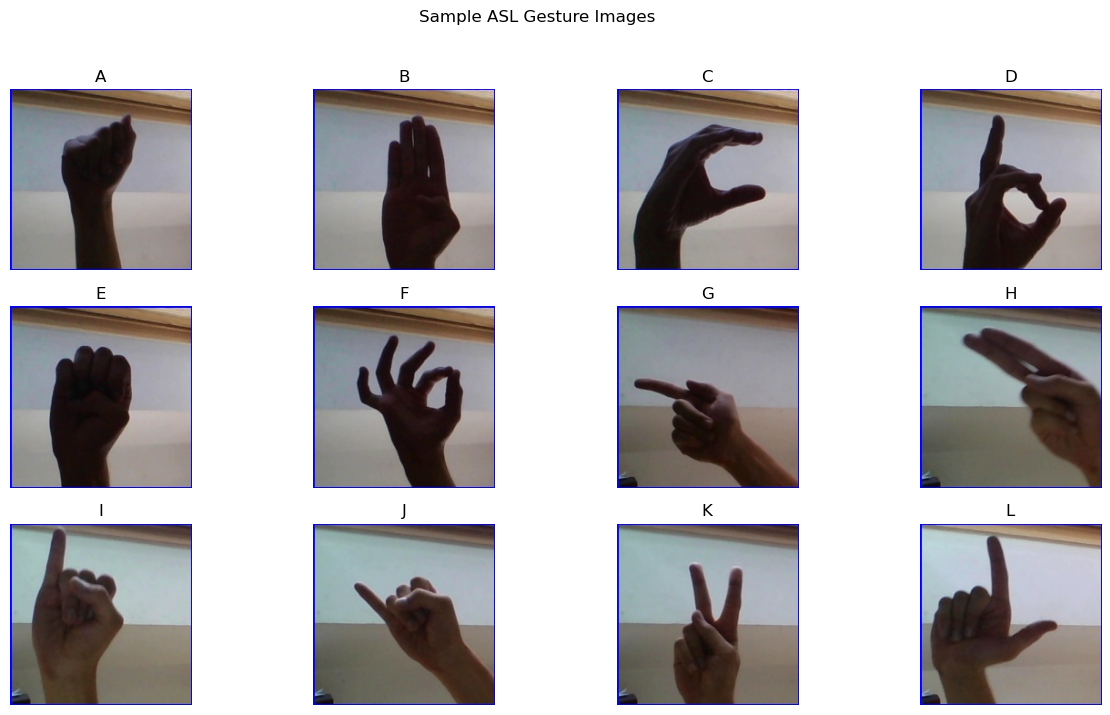

In [10]:
plt.figure(figsize=(15,8))

for i, label in enumerate(labels[:12]):
    img_path = df[df['Label'] == label]['Path'].iloc[0]
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.title(label)
    plt.axis('off')

plt.suptitle("Sample ASL Gesture Images")
plt.show()


In [11]:
df[['Height', 'Width']].describe()


,Height,Width
count,87000.0,87000.0
mean,200.0,200.0
std,0.0,0.0
min,200.0,200.0
25%,200.0,200.0
50%,200.0,200.0
75%,200.0,200.0
max,200.0,200.0


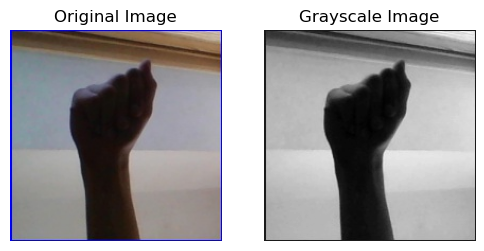

In [12]:
sample_path = df.iloc[0]['Path']
img = cv2.imread(sample_path)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()


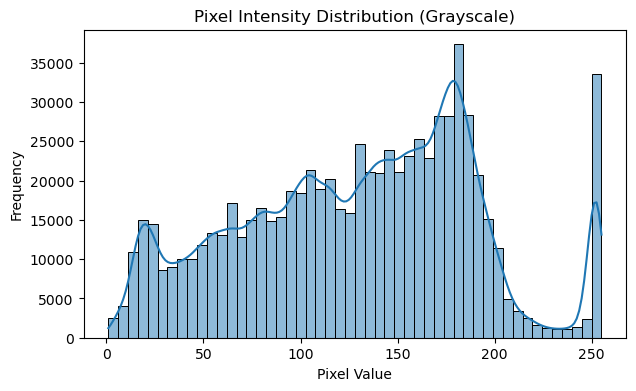

In [13]:
pixel_values = []

sample_df = df.sample(300)

for path in sample_df['Path']:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, IMAGE_SIZE)
    pixel_values.extend(img.flatten())

plt.figure(figsize=(7,4))
sns.histplot(pixel_values, bins=50, kde=True)
plt.title("Pixel Intensity Distribution (Grayscale)")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


In [14]:
import os
import pandas as pd

labels = os.listdir(DATASET_PATH)
counts = {}

for label in labels:
    counts[label] = len(os.listdir(os.path.join(DATASET_PATH, label)))

df = pd.DataFrame.from_dict(counts, orient='index', columns=['Images'])
df['Percentage'] = (df['Images'] / df['Images'].sum()) * 100

df.sort_values(by='Images', ascending=False)


,Images,Percentage
A,3000,3.448276
nothing,3000,3.448276
Y,3000,3.448276
X,3000,3.448276
W,3000,3.448276
V,3000,3.448276
U,3000,3.448276
T,3000,3.448276
space,3000,3.448276
S,3000,3.448276


In [15]:
print("Top 5 classes with most images:")
print(df.sort_values(by='Images', ascending=False).head())

print("\nTop 5 classes with least images:")
print(df.sort_values(by='Images').head())


Top 5 classes with most images:
         Images  Percentage
A          3000    3.448276
nothing    3000    3.448276
Y          3000    3.448276
X          3000    3.448276
W          3000    3.448276

Top 5 classes with least images:
   Images  Percentage
A    3000    3.448276
X    3000    3.448276
W    3000    3.448276
V    3000    3.448276
U    3000    3.448276


In [16]:
import cv2
import numpy as np

avg_sizes = []

for label in labels:
    heights, widths = [], []

    for img_name in os.listdir(os.path.join(DATASET_PATH, label))[:30]:
        img = cv2.imread(os.path.join(DATASET_PATH, label, img_name))
        h, w, _ = img.shape
        heights.append(h)
        widths.append(w)

    avg_sizes.append([label, np.mean(heights), np.mean(widths)])

size_df = pd.DataFrame(avg_sizes, columns=['Label', 'Avg Height', 'Avg Width'])
size_df


,Label,Avg Height,Avg Width
0,A,200.0,200.0
1,B,200.0,200.0
2,C,200.0,200.0
3,D,200.0,200.0
4,del,200.0,200.0
5,E,200.0,200.0
6,F,200.0,200.0
7,G,200.0,200.0
8,H,200.0,200.0
9,I,200.0,200.0


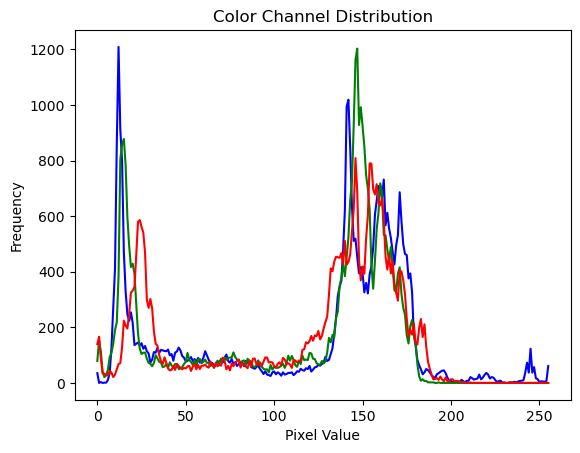

In [17]:
import matplotlib.pyplot as plt

img_path = os.path.join(DATASET_PATH, labels[0], os.listdir(os.path.join(DATASET_PATH, labels[0]))[0])
img = cv2.imread(img_path)

colors = ('b','g','r')
for i, col in enumerate(colors):
    hist = cv2.calcHist([img],[i], None, [256], [0,256])
    plt.plot(hist, color=col)

plt.title("Color Channel Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()


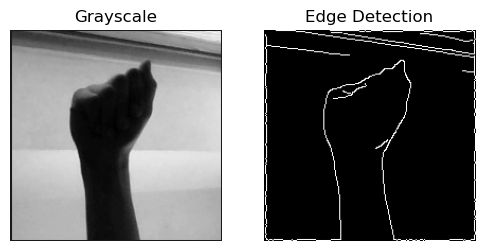

In [18]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edge Detection")
plt.axis("off")
plt.show()


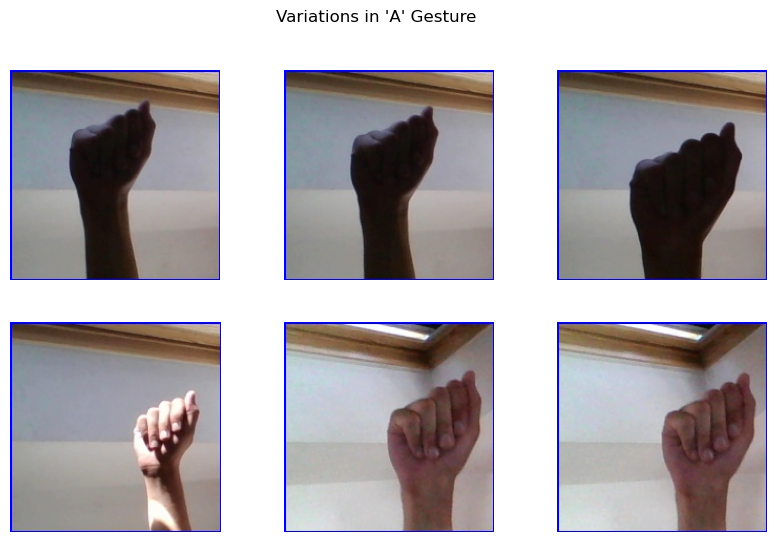

In [19]:
plt.figure(figsize=(10,6))

for i in range(6):
    img_path = os.path.join(
        DATASET_PATH,
        labels[0],
        os.listdir(os.path.join(DATASET_PATH, labels[0]))[i]
    )
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.suptitle(f"Variations in '{labels[0]}' Gesture")
plt.show()


In [20]:
import os

total_size = 0

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files:
        total_size += os.path.getsize(os.path.join(root, f))

print(f"Dataset Size: {total_size / (1024**2):.2f} MB")


Dataset Size: 1054.90 MB
